In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.inspection import DecisionBoundaryDisplay, permutation_importance

In [54]:
# Load the UCI Heart Disease dataset
df = pd.read_csv("heart_disease_uci.csv")

# display rows and shape
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"\nClass distribution (target: num):")
print(df['num'].value_counts())

# Display dataset
df

Rows: 920
Columns: 16

Class distribution (target: num):
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [55]:
# Target Engineering: Convert 'num' to binary (0 = healthy, 1 = disease)
df['target'] = (df['num'] > 0).astype(int)

# Select the standard 14 columns as mentioned in your project description
# These are the classic features used in the UCI Heart Disease study
features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
            'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
X = df[features]
y = df['target']

# convert categorical columns into numeric
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'bool']).columns.tolist()

# Define Imputing and Scaling (Range Normalization)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Step 3: Imputing
    ('scaler', StandardScaler())                    # Step 3: Normalization
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape:  {y.shape}")
print(f"Features used: {list(X.columns)}")
df

Feature matrix shape: (920, 13)
Target vector shape:  (920,)
Features used: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,target
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,1
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2,1
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0,0


In [56]:
# Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Training set size:  {X_train.shape[0]} samples")
print(f"Test set size:      {X_test.shape[0]} samples")
print(f"\nTraining class distribution:\n{y_train.value_counts()}")
print(f"\nTest class distribution:\n{y_test.value_counts()}")

Training set size:  644 samples
Test set size:      276 samples

Training class distribution:
target
1    353
0    291
Name: count, dtype: int64

Test class distribution:
target
1    156
0    120
Name: count, dtype: int64


In [57]:
# A dictionary of grids for all models
# 1. Define a dictionary of models and their parameter grids
model_params = {
    "K-Nearest Neighbors": {
        "model": KNeighborsClassifier(),
        "params": {
            "classifier__n_neighbors": [3, 5, 7, 11, 15],
            "classifier__weights": ['uniform', 'distance'],
            "classifier__metric": ['euclidean', 'manhattan']
        }
    },
    "SVM": {
        "model": SVC(),
        "params": {
            "classifier__C": [0.1, 1, 10],
            "classifier__kernel": ['linear', 'rbf'],
            "classifier__gamma": ['scale', 'auto']
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "classifier__n_estimators": [50, 100, 200],
            "classifier__max_depth": [None, 10, 20]
        }
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "classifier__max_depth": [None, 5, 10],
            "classifier__criterion": ['gini', 'entropy']
        }
    },
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000),
        "params": {
            "classifier__C": [0.1, 1, 10],
            "classifier__solver": ['liblinear', 'lbfgs']
        }
    }
}

# 2. Loop through the models to find the best settings
tuning_results = []

for name, mp in model_params.items():
    # Create the pipeline for this specific model
    clf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                   ('classifier', mp['model'])])

    # Run Grid Search (Step 8: Hyperparameter Tuning)
    grid = GridSearchCV(clf_pipeline, mp['params'], cv=5, scoring='accuracy')
    grid.fit(X_train, y_train)

    # Store results
    tuning_results.append({
        'Model': name,
        'Best Params': grid.best_params_,
        'Tuned Accuracy': grid.score(X_test, y_test)
    })

# 3. Display Final Comparison
results_df = pd.DataFrame(tuning_results)

# Show best parameters
print("Best Parameters:", grid.best_params_)
print(f"\nBest cross-validated recall score: {grid.best_score_:.4f}")
print(f"Test set recall score: {grid.score(X_test, y_test):.4f}")
print()
print(results_df[['Model', 'Tuned Accuracy']])

Best Parameters: {'classifier__C': 0.1, 'classifier__solver': 'liblinear'}

Best cross-validated recall score: 0.8215
Test set recall score: 0.8043

                 Model  Tuned Accuracy
0  K-Nearest Neighbors        0.855072
1                  SVM        0.826087
2        Random Forest        0.818841
3        Decision Tree        0.778986
4  Logistic Regression        0.804348


In [58]:
# Loop through models, tune, and generate full reports
for name, mp in model_params.items():
    clf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                   ('classifier', mp['model'])])

    # Tuning
    grid = GridSearchCV(clf_pipeline, mp['params'], cv=5, scoring='accuracy')
    grid.fit(X_train, y_train)

    # 1. Prediction using the 'best_estimator_' found by GridSearch
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    # 2. Print Detailed Reports
    print(f"\n{'='*20} {name} {'='*20}")
    print(f"Best Parameters: {grid.best_params_}")
    print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


==================== K-Nearest Neighbors ====================
Best Parameters: {'classifier__metric': 'manhattan', 'classifier__n_neighbors': 15, 'classifier__weights': 'uniform'}
Test Accuracy: 0.8551

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.84       120
           1       0.88      0.86      0.87       156

    accuracy                           0.86       276
   macro avg       0.85      0.85      0.85       276
weighted avg       0.86      0.86      0.86       276

Confusion Matrix:
[[102  18]
 [ 22 134]]

==================== SVM ====================
Best Parameters: {'classifier__C': 1, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
Test Accuracy: 0.8261

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.81      0.80       120
           1       0.85      0.84      0.85       156

    accuracy                           0.83       2

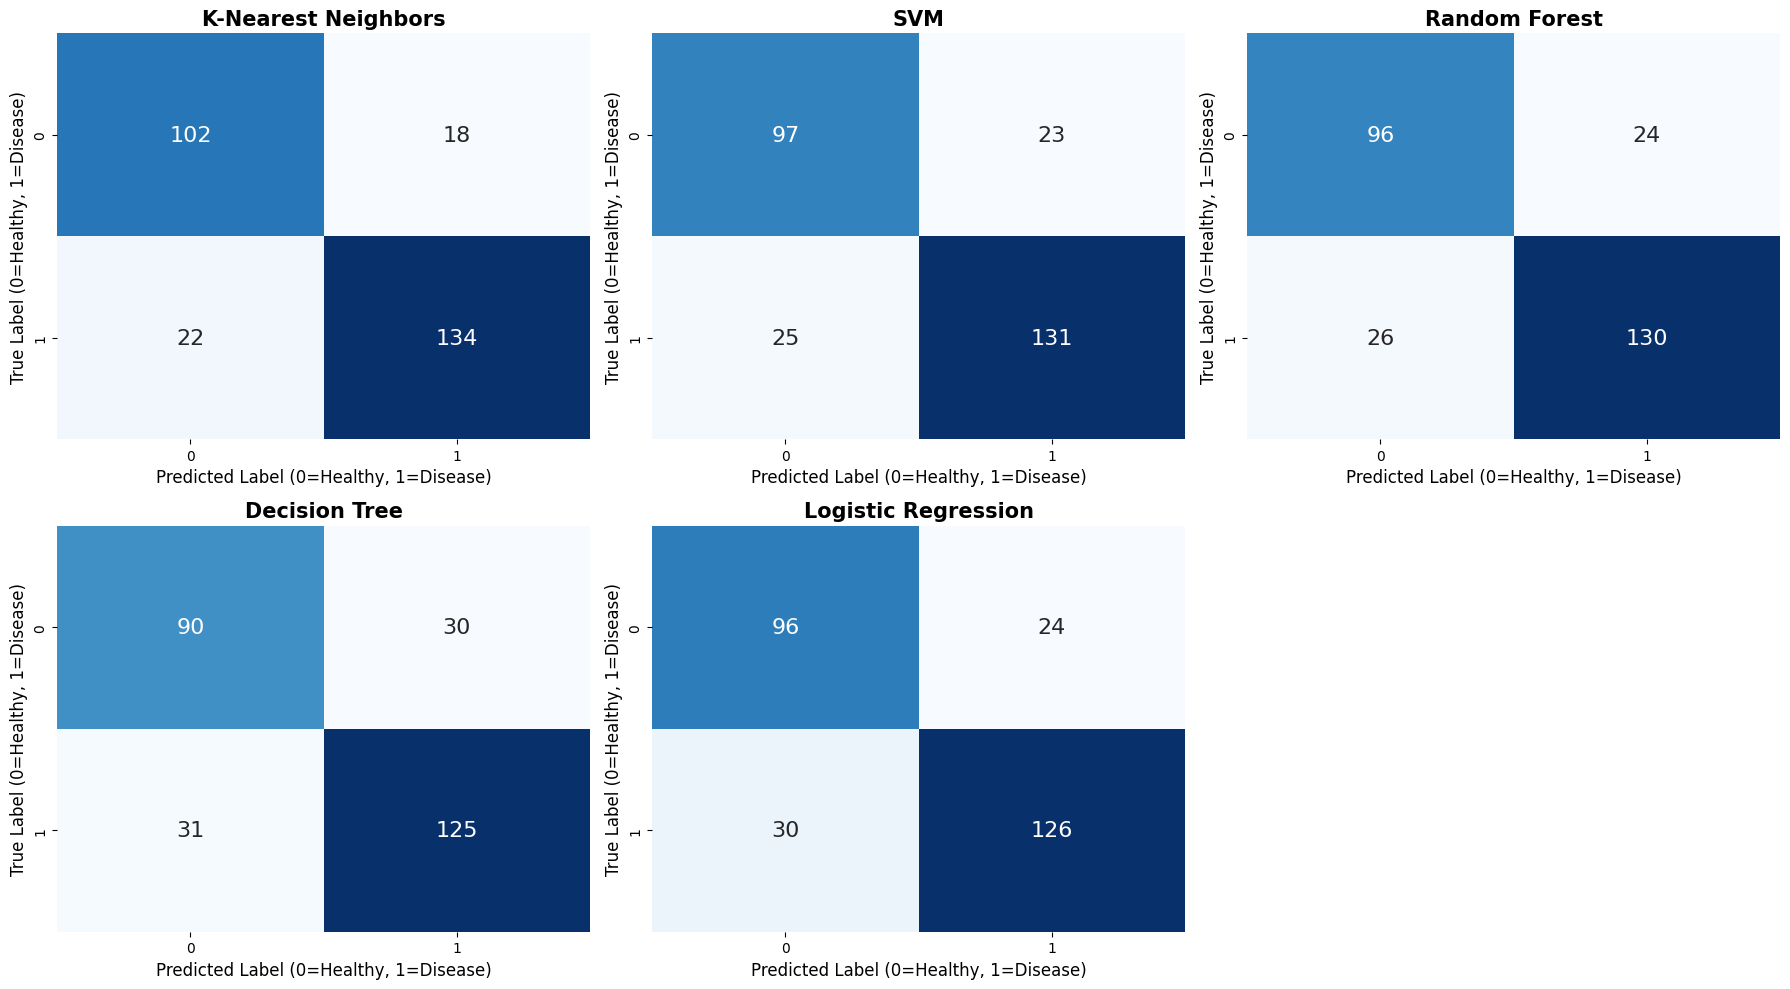

In [59]:
# Prepare data for visualization
model_names = []
accuracies = []
predictions_dict = {}

# Re-running the best predictions to store them for plotting
for name, mp in model_params.items():
    clf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                   ('classifier', mp['model'])])

    # Fit the grid search again (or you can modify your original loop to save 'y_pred')
    grid = GridSearchCV(clf_pipeline, mp['params'], cv=5, scoring='accuracy')
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    model_names.append(name)
    accuracies.append(grid.score(X_test, y_test))
    predictions_dict[name] = y_pred

# ==========================================
# VISUALIZATION 1: Heatmap Confusion Matrix
# ==========================================
# Create a 2x3 grid of subplots for our 5 models
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten() # Flatten the 2D array of axes for easy looping

for i, name in enumerate(model_names):
    # Calculate confusion matrix
    cm = confusion_matrix(y_test, predictions_dict[name])

    # Plot heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                cbar=False, annot_kws={"size": 16})

    axes[i].set_title(f'{name}', fontsize=15, fontweight='bold')
    axes[i].set_xlabel('Predicted Label (0=Healthy, 1=Disease)', fontsize=12)
    axes[i].set_ylabel('True Label (0=Healthy, 1=Disease)', fontsize=12)

# We only have 5 models, so we hide the 6th empty subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()

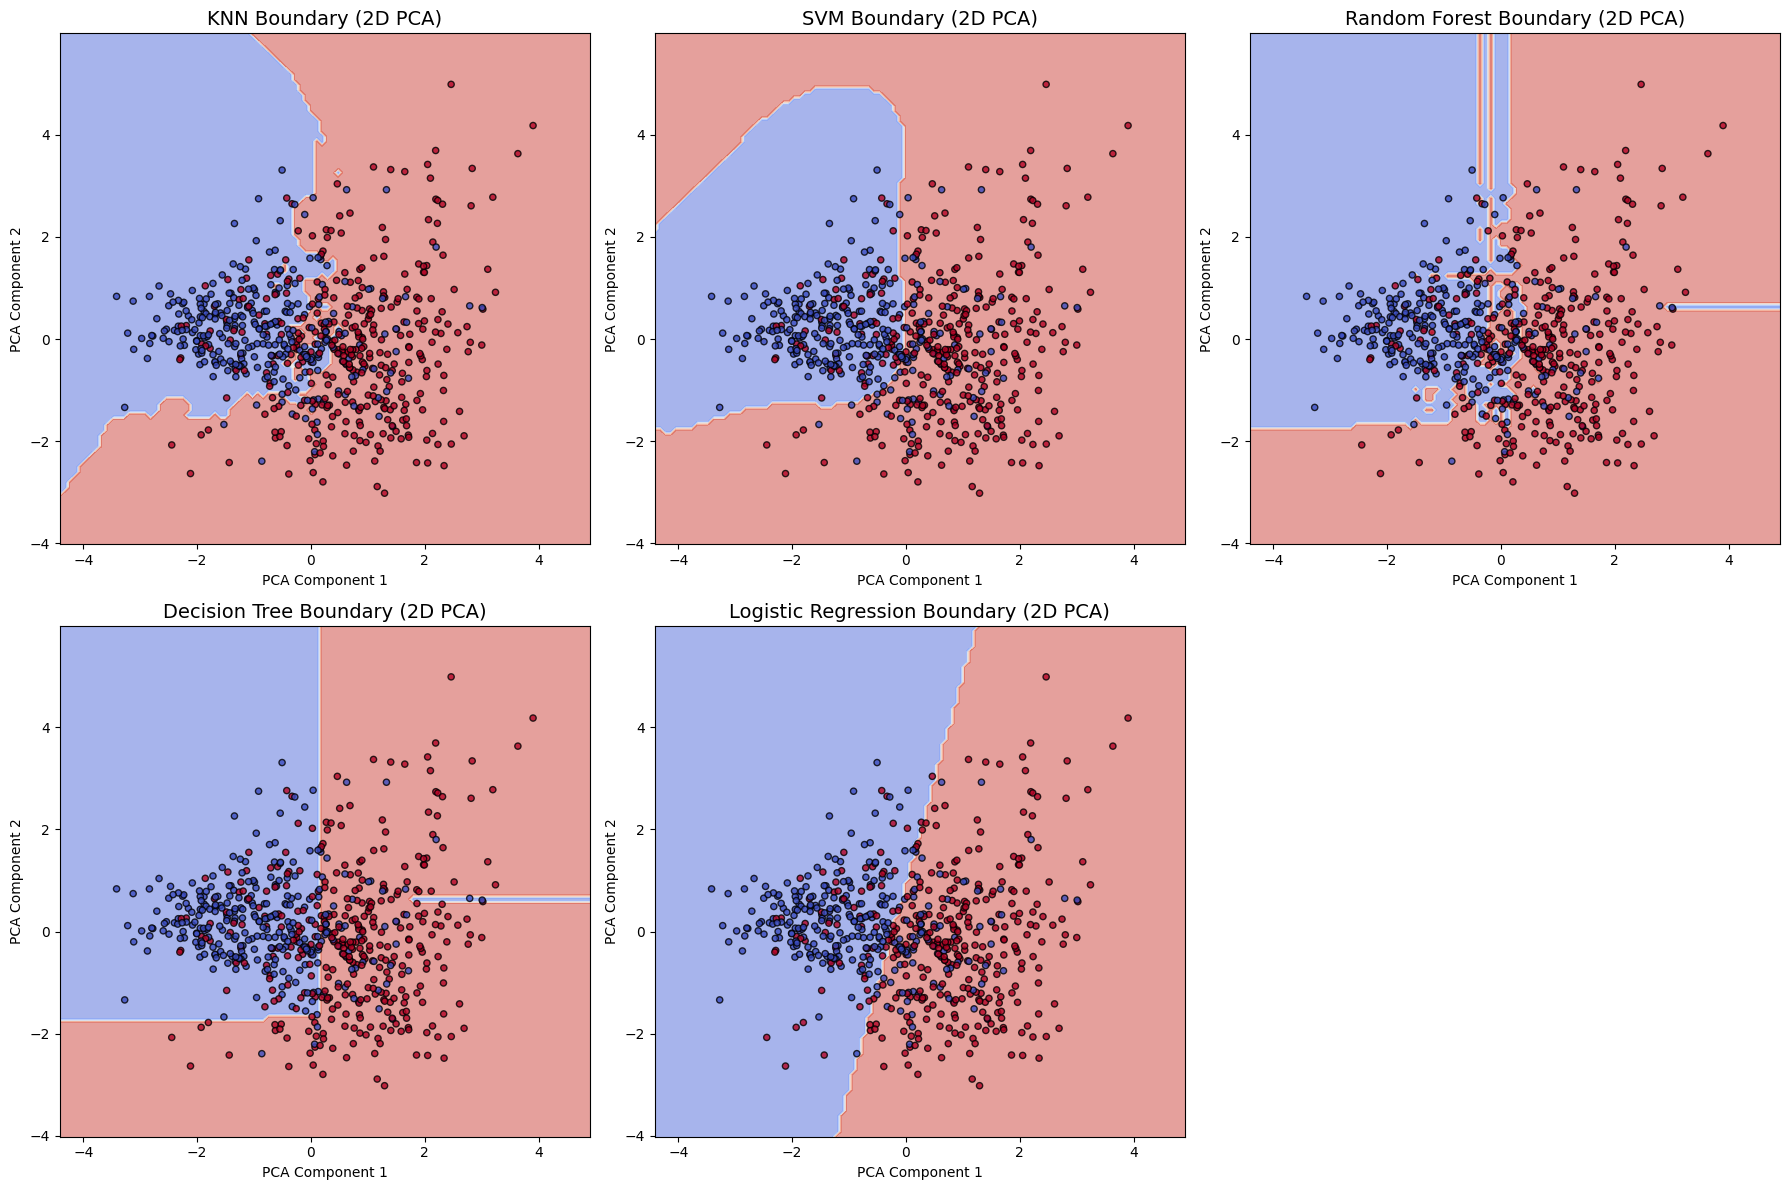

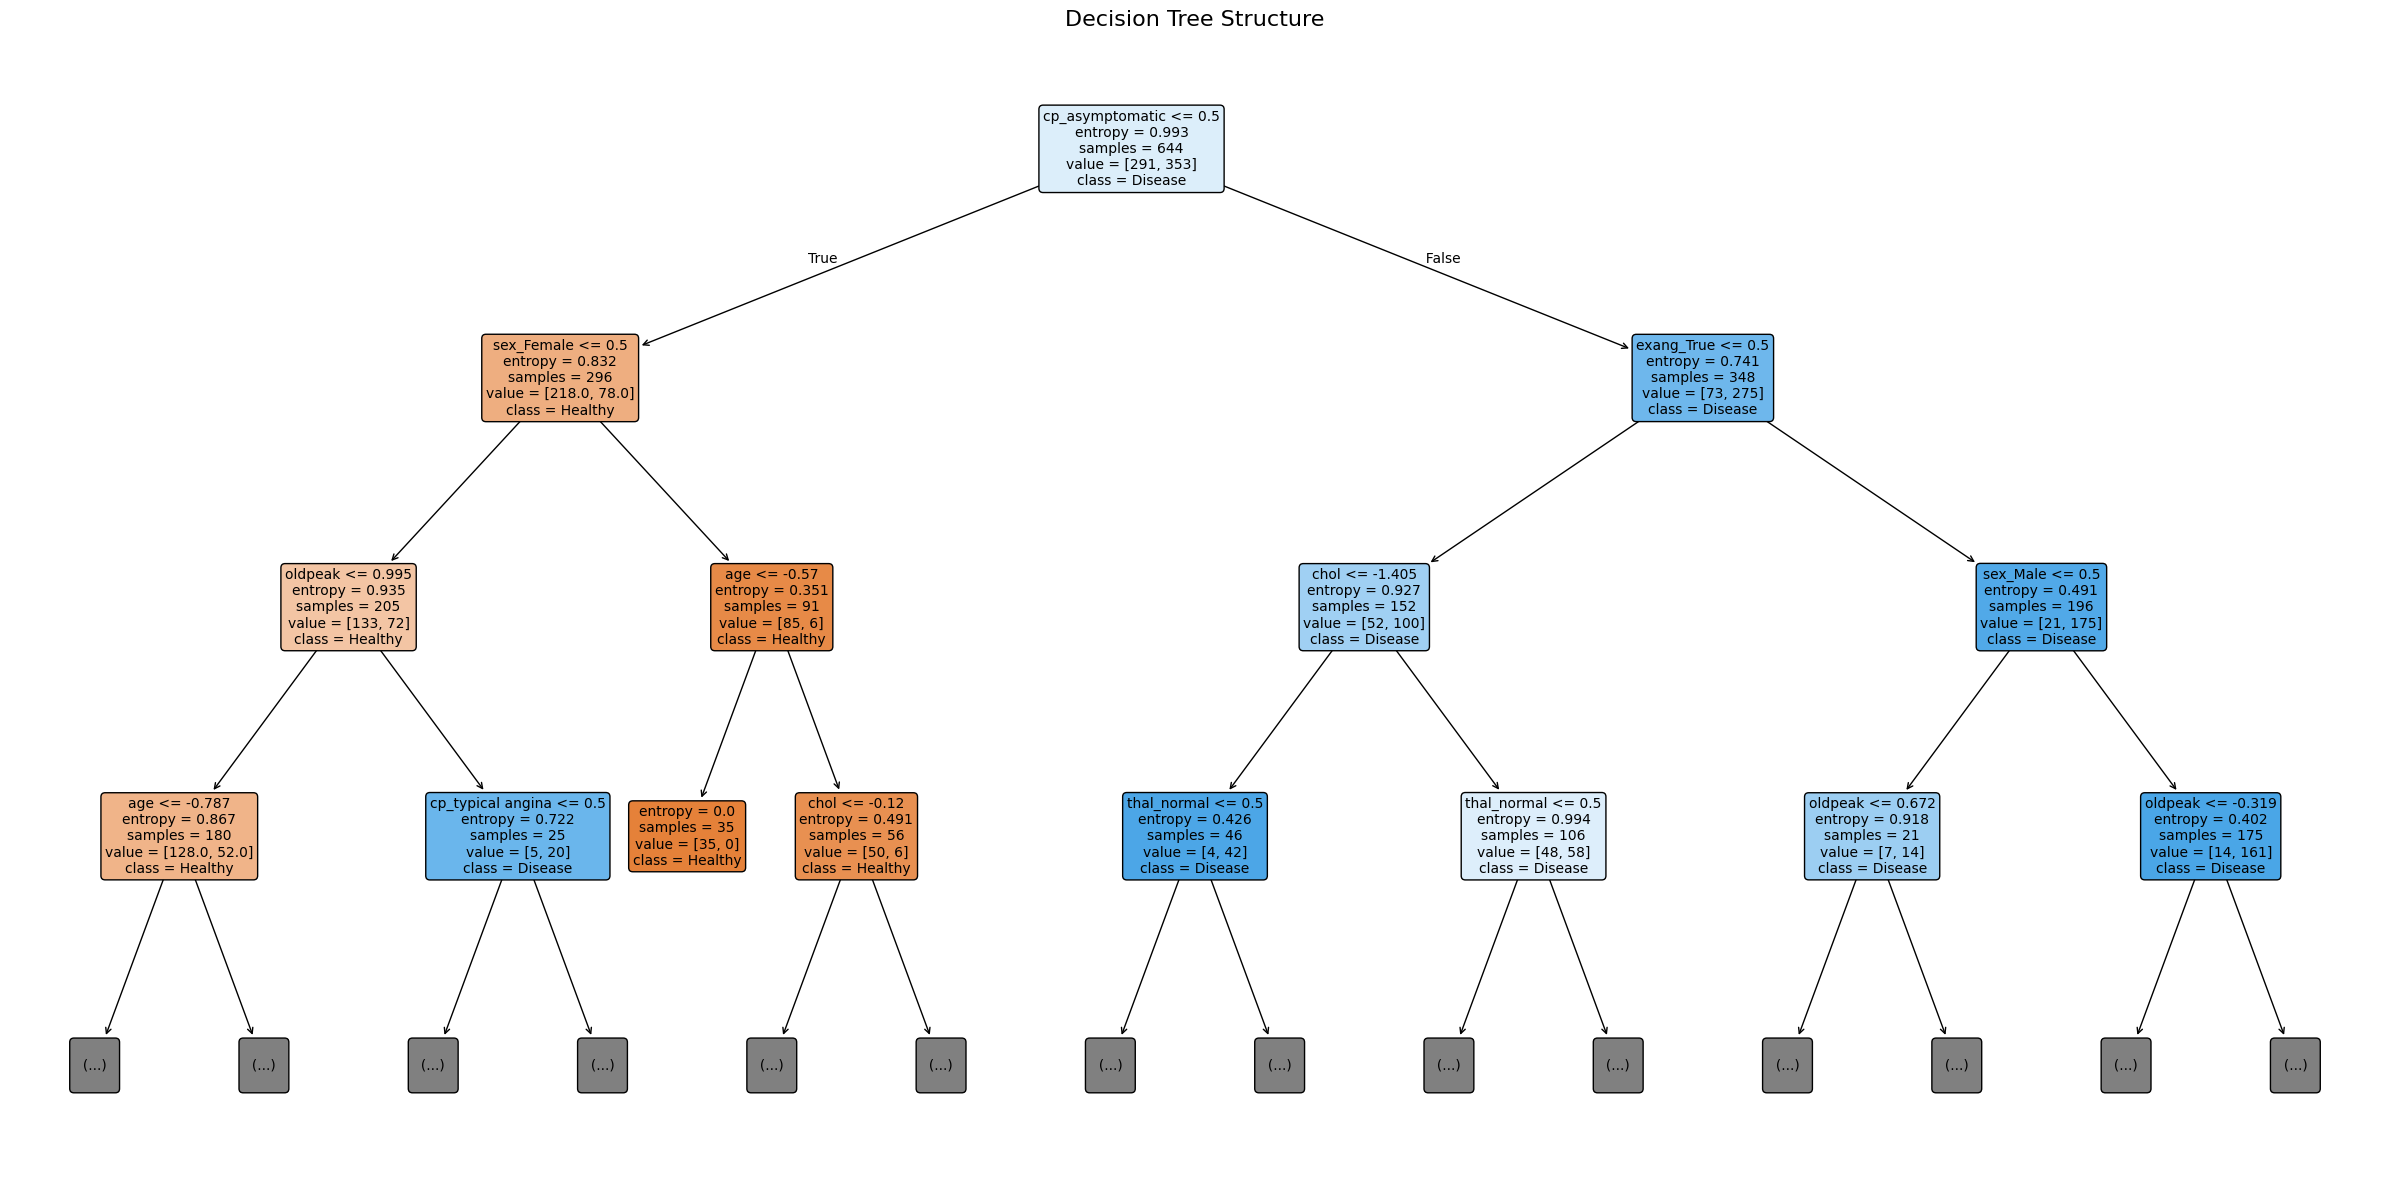

In [60]:
best_models = {
    "KNN": KNeighborsClassifier(n_neighbors=11, metric='euclidean', weights='uniform'),
    "SVM": SVC(C=1, gamma='scale', kernel='rbf'),
    "Random Forest": RandomForestClassifier(n_estimators=100, min_samples_split=5, random_state=42),
    "Decision Tree": DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_split=10, random_state=42),
    "Logistic Regression": LogisticRegression(C=0.1, solver='liblinear')
}

# ==========================================
# VISUALIZATION 2: Model Decision Boundaries
# ==========================================
# Reduce 13D data down to 2D using PCA
X_train_trans = preprocessor.fit_transform(X_train)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_trans)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (name, model) in enumerate(best_models.items()):
    # Train the model directly on the 2D PCA data for visualization
    model.fit(X_train_pca, y_train)

    # Draw the boundary
    DecisionBoundaryDisplay.from_estimator(
        model, X_train_pca, response_method="predict",
        cmap=plt.cm.coolwarm, alpha=0.5, ax=axes[idx],
        xlabel='PCA Component 1', ylabel='PCA Component 2'
    )
    # Scatter the actual data points over the boundaries
    axes[idx].scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap=plt.cm.coolwarm, edgecolors='k', s=20, alpha=0.8)
    axes[idx].set_title(f'{name} Boundary (2D PCA)', fontsize=14)

axes[5].axis('off')
plt.tight_layout()
plt.show()

# ==========================================
# VISUALIZATION 3: Decision Tree Structure
# ==========================================
clf_dt = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', best_models["Decision Tree"])])
clf_dt.fit(X_train, y_train)

# Extract the feature names so the tree is readable
feature_names = clf_dt.named_steps['preprocessor'].get_feature_names_out()
feature_names = [name.replace('num__', '').replace('cat__', '') for name in feature_names]

plt.figure(figsize=(24, 12))
plot_tree(clf_dt.named_steps['classifier'],
          feature_names=feature_names,
          class_names=['Healthy', 'Disease'],
          filled=True, rounded=True, max_depth=3, fontsize=10) # Truncated to depth 3 so it fits on screen
plt.title('Decision Tree Structure', fontsize=16)
plt.tight_layout()
plt.show()

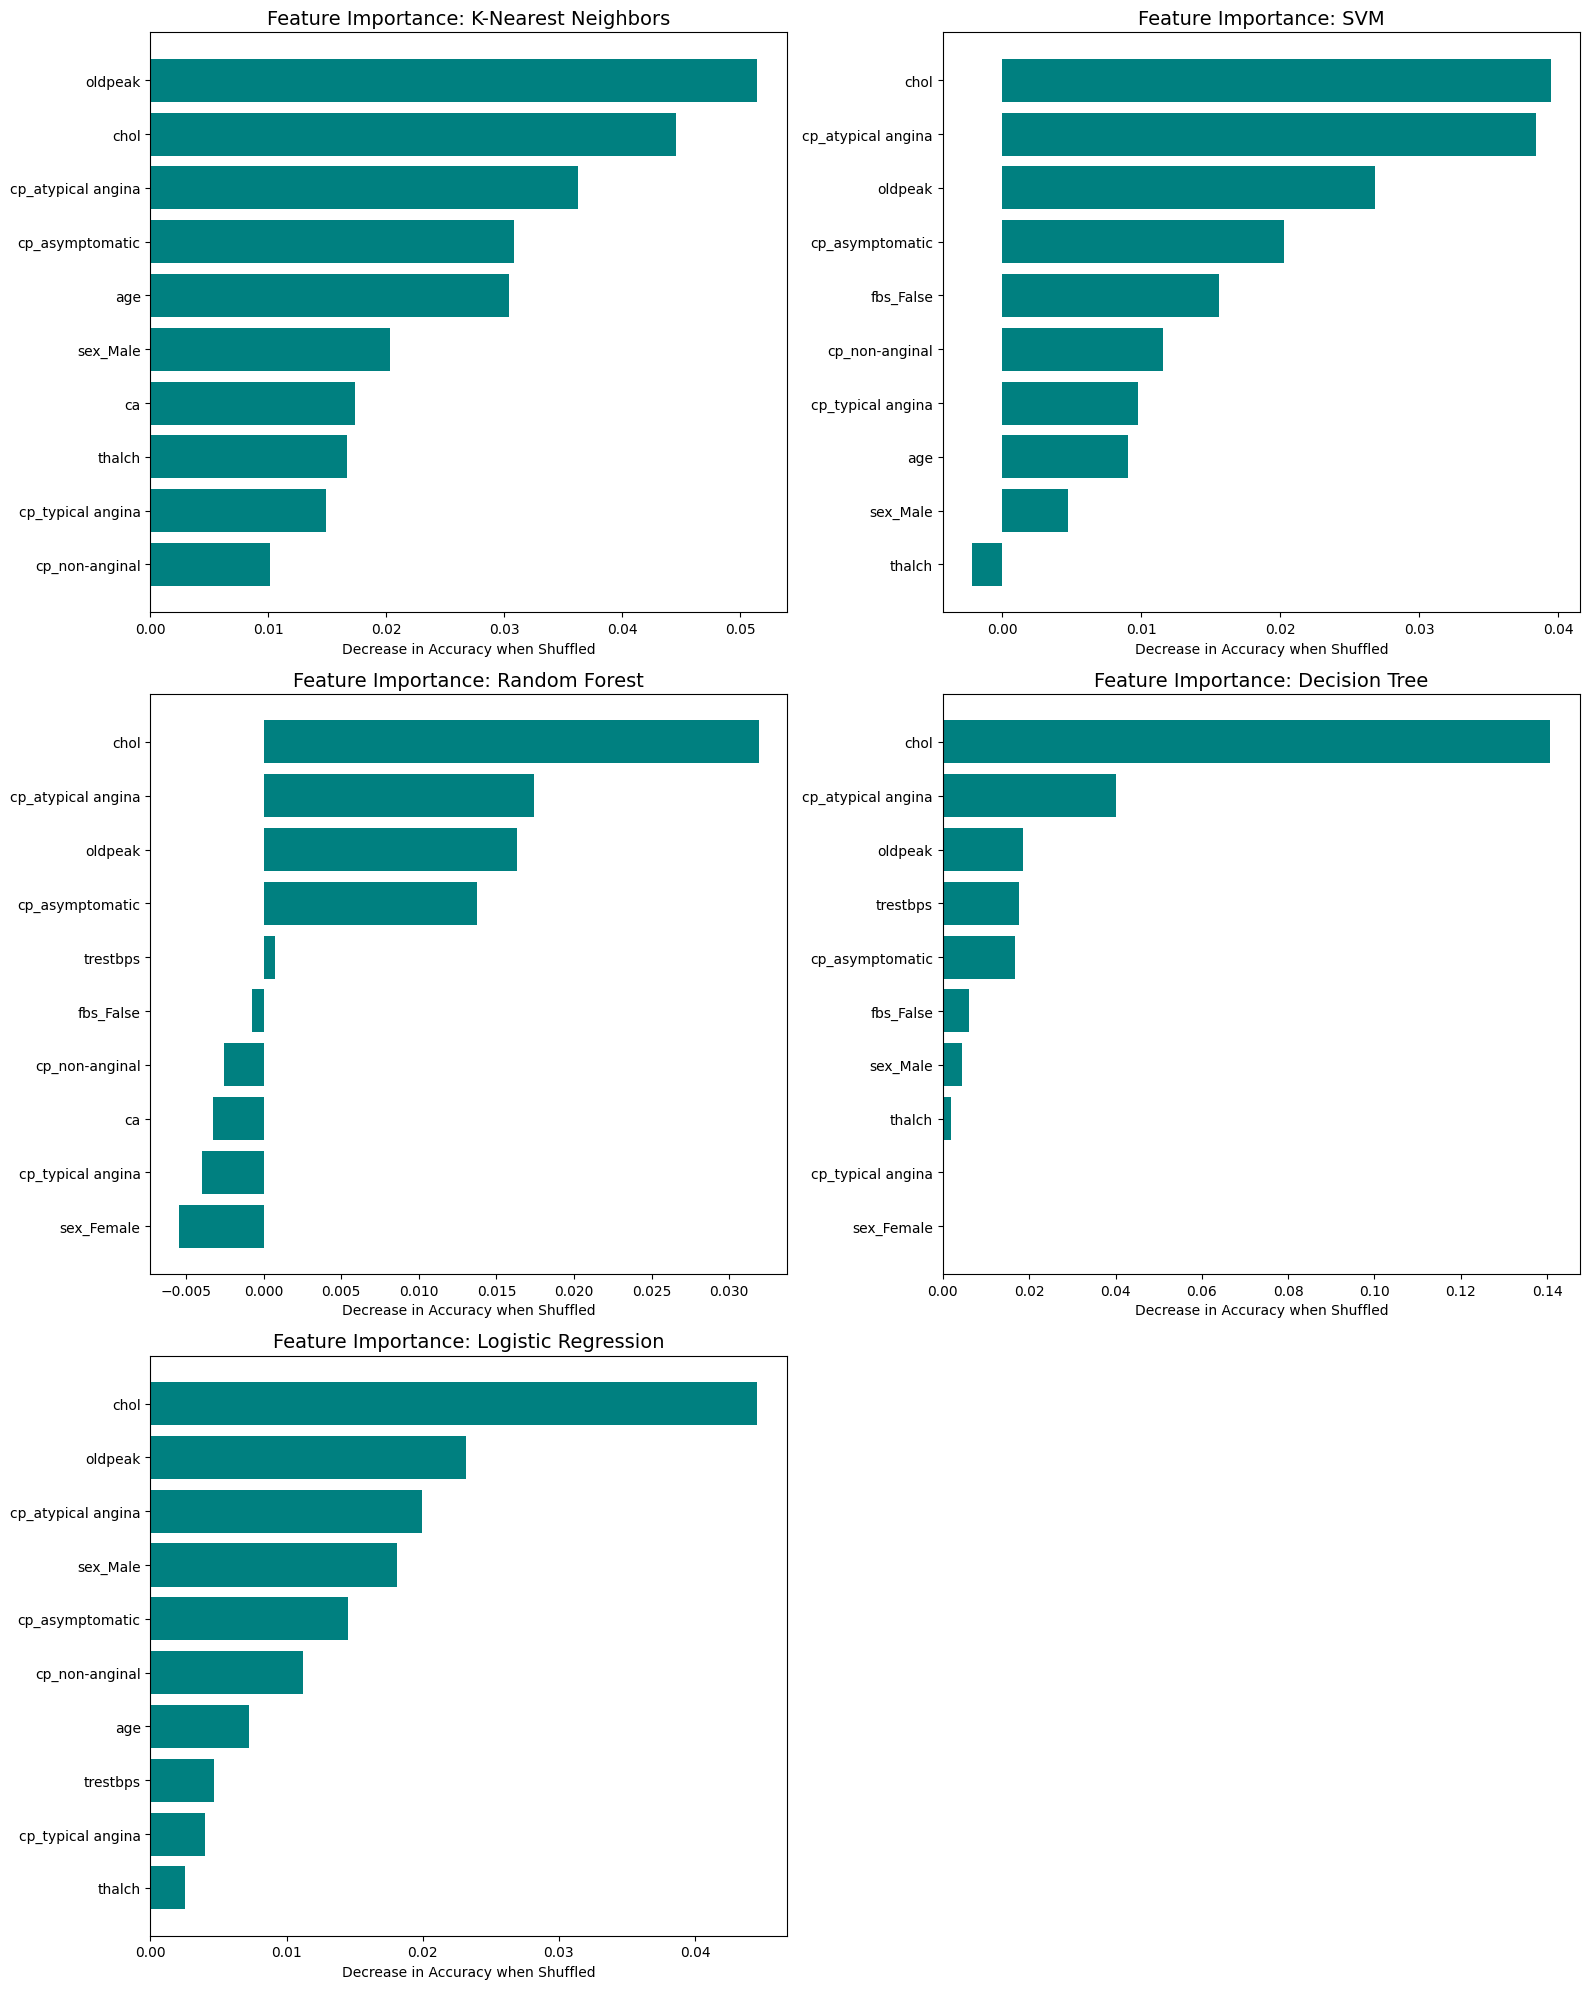

In [61]:
# Identify which features are most important in prediction

# 1. Define your best models
models = {
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=11),
    "SVM": SVC(C=1, kernel='rbf'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Logistic Regression": LogisticRegression(C=0.1, solver='liblinear')
}

# 2. Setup the Plotting Area
fig, axes = plt.subplots(3, 2, figsize=(16, 20))
axes = axes.flatten()

# Get feature names after they were processed by the preprocessor
preprocessor.fit(X_train)
feature_names = preprocessor.get_feature_names_out()
clean_names = [n.replace('num__', '').replace('cat__', '') for n in feature_names]

# 3. Loop through models and calculate Permutation Importance
for i, (name, model) in enumerate(models.items()):
    # Create and fit the pipeline
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipe.fit(X_train, y_train)

    # Calculate Permutation Importance on the Test Set
    # n_repeats=10 means we shuffle each column 10 times to get a stable average
    result = permutation_importance(pipe, X_test, y_test, n_repeats=10, random_state=42)

    # Sort features by importance (taking top 10)
    sorted_idx = result.importances_mean.argsort()[-10:]

    # Create Bar Chart
    axes[i].barh(np.array(clean_names)[sorted_idx], result.importances_mean[sorted_idx], color='teal')
    axes[i].set_title(f"Feature Importance: {name}", fontsize=14)
    axes[i].set_xlabel("Decrease in Accuracy when Shuffled", fontsize=10)

# Clean up layout
axes[5].axis('off')
plt.tight_layout()
plt.show()